# Notebook 03 - Data Training

In this notebook we perform the training our data using the method of Logistic Regression. 

## Setup

In [37]:
# General
import numpy as np                     
import pandas as pd      
import re              

# Plotting Options
from matplotlib import pyplot as plt                           
import seaborn as sns                                          
plt.rcParams['text.usetex'] = True                             
plt.rcParams['text.latex.preamble'] = r'\usepackage{amsmath}'  

# File management
from pathlib import Path                  
import os                     

# Machine learning tools 

from sklearn.model_selection import RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_extraction import text
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import joblib
from scipy.stats import loguniform
import tempfile

# Defines a function to find the project root directory by looking for a specific marker (default is 'data')
def find_project_root(start=Path.cwd(), marker='data'): 
    current = start
    while current != current.parent:
        if (current / marker).exists():
            return current
        current = current.parent
    raise FileNotFoundError("Project root not found")

PROJECT_ROOT = find_project_root() 
os.chdir(PROJECT_ROOT) # go to the root of the project 

In [38]:
df_reviews = pd.read_csv('data/dataframes/gold/reviews.csv')

In [39]:
df_reviews.head()

,unique_id,asin,helpful,rating,reviewText,reviewTime,reviewerID,reviewerName,summary,unixReviewTime,normalized_review_time,normalized_review
0,11539,B0033UV8HI,"[8, 10]",3,"Jace Rankin may be short, but he's nothing to ...","09 2, 2010",A3HHXRELK8BHQG,Ridley,Entertaining But Average,1283385600,2010-09-02,jace rankin may be short but hes nothing to me...
1,5957,B002HJV4DE,"[1, 1]",5,Great short read. I didn't want to put it dow...,"10 8, 2013",A2RGNZ0TRF578I,Holly Butler,Terrific menage scenes!,1381190400,2013-10-08,great short read i didnt want to put it down s...
2,9146,B002ZG96I4,"[0, 0]",3,I'll start by saying this is the first of four...,"04 11, 2014",A3S0H2HV6U1I7F,Merissa,Snapdragon Alley,1397174400,2014-04-11,ill start by saying this is the first of four ...
3,7038,B002QHWOEU,"[1, 3]",3,Aggie is Angela Lansbury who carries pocketboo...,"07 5, 2014",AC4OQW3GZ919J,Cleargrace,very light murder cozy,1404518400,2014-07-05,aggie is angela lansbury who carries pocketboo...
4,1776,B001A06VJ8,"[0, 1]",4,I did not expect this type of book to be in li...,"12 31, 2012",A3C9V987IQHOQD,Rjostler,Book,1356912000,2012-12-31,i did not expect this type of book to be in li...


## 1. Splitting data into test and train

In [40]:
# defining inputs and outputs

X = df_reviews['normalized_review']
y = df_reviews['rating']

In [41]:
# splitting into test and train 

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=0, stratify=y)

## 2. Defining the pipeline

In our pipeline we will add three processes to be made. 

    1. Vectorization: we need to convert the characters on the reviews into numbers in order to perform our analysis. The stop words, that is, words that need not to be converted will articles, connectors and so on. 
    
    2. Scaler: after the vectorization we standardize all of our vectors. StandardScaler adjust the scale of every number so they have an equal variance.

    3. Logistic Regression: this step applies the method of Logistic Regression to train our model. 

The stops words can be obtained with the command text.ENGLISH_STOP_WORDS. But this is not good for a sentiment analysis since those include words like "not", "no" and so on and this could be bad for negative reviews. Instead, we will define the stop words as 

In [42]:
stopwords = set(text.ENGLISH_STOP_WORDS) - {
    'not', 'no', 'nor', 'never', "n't"
}

Now we can apply to the pipeline. The TF-IDF transformation is repeated on every fold. Thus use memory caching in the pipeline so it is computed once per parameter combination

In [43]:
cache_dir = tempfile.mkdtemp()

In [44]:
pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(stop_words=list(stopwords))),
    ('logreg', LogisticRegression(solver='saga', max_iter=5000, random_state=42))
], memory=cache_dir)

The thing is that LogisticRegression has several hyperparamaters ([consult here](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html)). Thus, we need to choose which will be the best to obtain an accurate model. We can test this using RandomizedSearchCV, which enables us to tune the hyperparameters with fixed combinations. This is more computationally efficient that GridSearchCV since we have a lot of parameters.

We define a dictionary to store the parameters we want to test. Since TfidfVectorizer also takes parameters, we add combinations for those as well

In [45]:
param_distributions = {
    'tfidf__max_features': [500, 1000, 2000],
    'tfidf__ngram_range': [(1, 1), (1, 2)],
    'logreg__C': loguniform(0.01, 10),
    'logreg__penalty': ['l1', 'l2'],
}

In [46]:
# Setting up RandomizedSearchCV

random_search = RandomizedSearchCV(
    pipeline,
    param_distributions,
    n_iter=20,           
    cv=3,
    n_jobs=-1,
    scoring='accuracy',
    random_state=42,
    verbose=1
)

## 3. Training the model

Now we provide the pipeline with the training data. The GridSearchCV executes the process .fit() and learn how to connect the rating to its review.  

In [47]:
random_search.fit(X_train, y_train)

Fitting 3 folds for each of 20 candidates, totalling 60 fits


,estimator,Pipeline(memo...ver='saga'))])
,param_distributions,"{'logreg__C': <scipy.stats....x77b7da2c4510>, 'logreg__penalty': ['l1', 'l2'], 'tfidf__max_features': [500, 1000, ...], 'tfidf__ngram_range': [(1, ...), (1, ...)]}"
,n_iter,20
,scoring,'accuracy'
,n_jobs,-1
,refit,True
,cv,3
,verbose,1
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


The best parameters found were 

In [48]:
print("\nBest parameters found:\n")
print(random_search.best_params_)


Best parameters found:

{'logreg__C': np.float64(1.8453732926615927), 'logreg__penalty': 'l2', 'tfidf__max_features': 1000, 'tfidf__ngram_range': (1, 2)}


Then we define the best model

In [50]:
best_model = random_search.best_estimator_

## 4. Model evaluation

We now perform our test using this model to see how accurate it is

In [51]:
y_pred = best_model.predict(X_test)

In [53]:
# Calculating metric 

accuracy = accuracy_score(y_test, y_pred)
report = classification_report(y_test, y_pred, target_names = ['1','2','3','4','5'])

In [56]:
print(f"\nModel Accuracy: {accuracy:.2%}\n")
print("Report of Classification:\n")
print(report)


Model Accuracy: 46.31%

Report of Classification:

              precision    recall  f1-score   support

           1       0.50      0.57      0.53       600
           2       0.39      0.35      0.37       600
           3       0.37      0.27      0.31       600
           4       0.42      0.43      0.42       900
           5       0.56      0.63      0.59       900

    accuracy                           0.46      3600
   macro avg       0.45      0.45      0.45      3600
weighted avg       0.45      0.46      0.46      3600



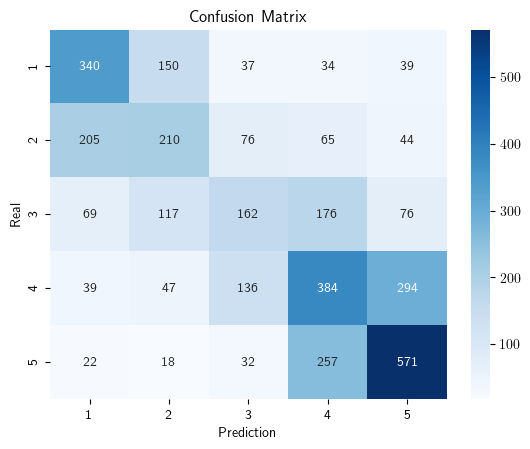

In [58]:
# Visualizar a Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot = True, fmt = 'd', cmap = 'Blues',
            xticklabels = ['1','2','3','4','5'],
            yticklabels = ['1','2','3','4','5'])
plt.xlabel('Prediction')
plt.ylabel('Real')
plt.title('Confusion Matrix')
plt.show()